# Matplotlib

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Pyplot style

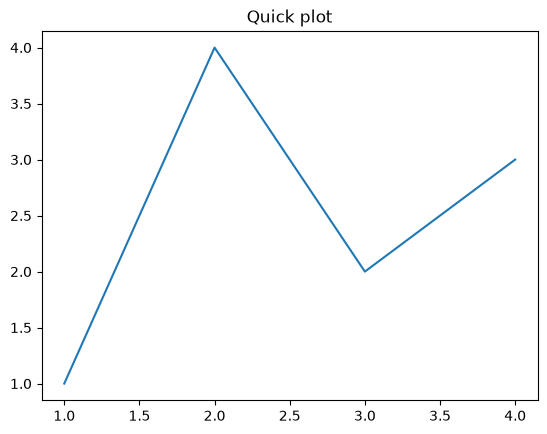

In [4]:
plt.plot([1, 2, 3, 4], [1, 4, 2, 3])
plt.title("Quick plot")
plt.show()

### OO style

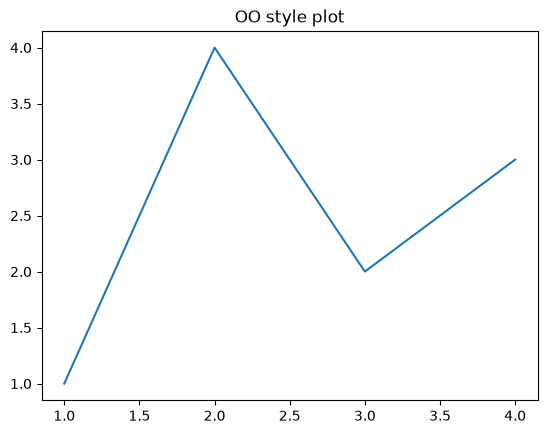

In [12]:
fig, ax = plt.subplots()          # fig = whole canvas, ax = the plotting area
ax.plot([1, 2, 3, 4], [1, 4, 2, 3])
ax.set_title("OO style plot")
plt.show()

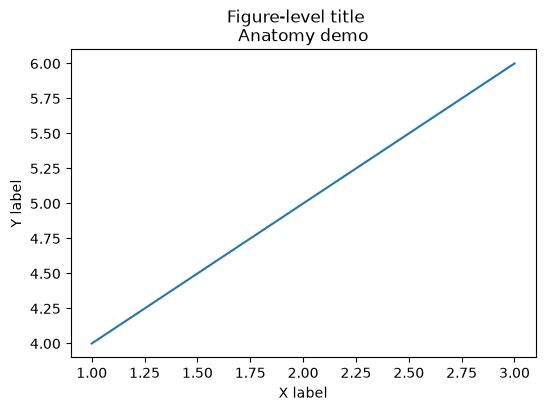

In [13]:
fig, ax = plt.subplots(figsize=(6, 4))   # figsize in inches
ax.plot([1, 2, 3], [4, 5, 6])
ax.set_xlabel("X label")
ax.set_ylabel("Y label")
ax.set_title("Anatomy demo")
fig.suptitle("Figure-level title")       # note: fig, not ax
plt.show()

### Core Plot Types (with your kind of data)

In [15]:
data = pd.read_csv('housing.csv')
data.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-120.55,34.26,28,1306,202.0,4701,753,3.4674,225172,INLAND
1,-114.79,37.65,7,2424,406.0,659,1628,1.3658,143644,<1H OCEAN
2,-116.98,40.79,35,397,93.0,2206,992,0.9720,118766,NEAR BAY


In [16]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           1000 non-null   float64
 1   latitude            1000 non-null   float64
 2   housing_median_age  1000 non-null   int64  
 3   total_rooms         1000 non-null   int64  
 4   total_bedrooms      985 non-null    float64
 5   population          1000 non-null   int64  
 6   households          1000 non-null   int64  
 7   median_income       1000 non-null   float64
 8   median_house_value  1000 non-null   int64  
 9   ocean_proximity     1000 non-null   str    
dtypes: float64(4), int64(5), str(1)
memory usage: 78.3 KB


In [20]:
data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,1000.00000,1000.00000,1000.000000,1000.000000,985.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,-119.39753,37.31663,26.675000,4045.135000,743.792893,2543.930000,908.483000,3.582854,248484.560000
std,2.92141,2.77589,14.959718,2170.030696,435.679497,1431.886547,499.324522,2.467040,108637.524658
min,-124.25000,32.53000,1.000000,207.000000,26.000000,51.000000,30.000000,0.500000,22998.000000
25%,-121.94250,34.79000,14.000000,2299.000000,406.000000,1277.750000,478.250000,1.742475,165190.750000
50%,-119.33500,37.42500,27.000000,3961.000000,708.000000,2564.500000,901.500000,3.097050,232778.000000
75%,-116.85750,39.72250,40.000000,5853.250000,1048.000000,3785.000000,1328.250000,4.759400,310095.250000
max,-114.30000,41.99000,52.000000,7986.000000,1979.000000,4993.000000,1799.000000,15.000000,500001.000000


In [19]:
columns , rows = data.shape
print(f"Columns : {columns}, Rows : {rows}")

Columns : 1000, Rows : 10


### Line Plot
#### Main purpose is to visualize the trend i.e. "How does something change?"

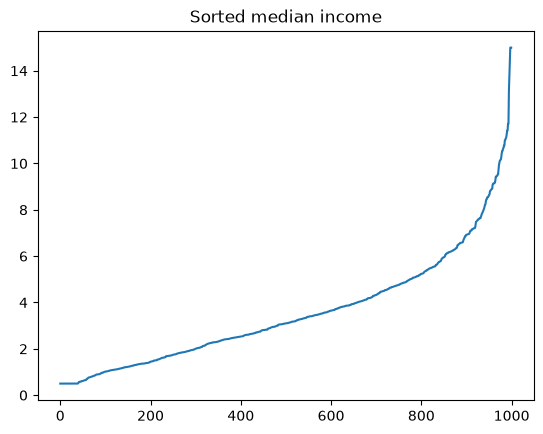

In [24]:
fig, ax = plt.subplots()
ax.plot(data['median_income'].sort_values().values)
ax.set_title("Sorted median income")
plt.show()

### Scatter plot
#### Main purpose is to visualize the relationship between two columns i.e. "Are X and Y aee related?"

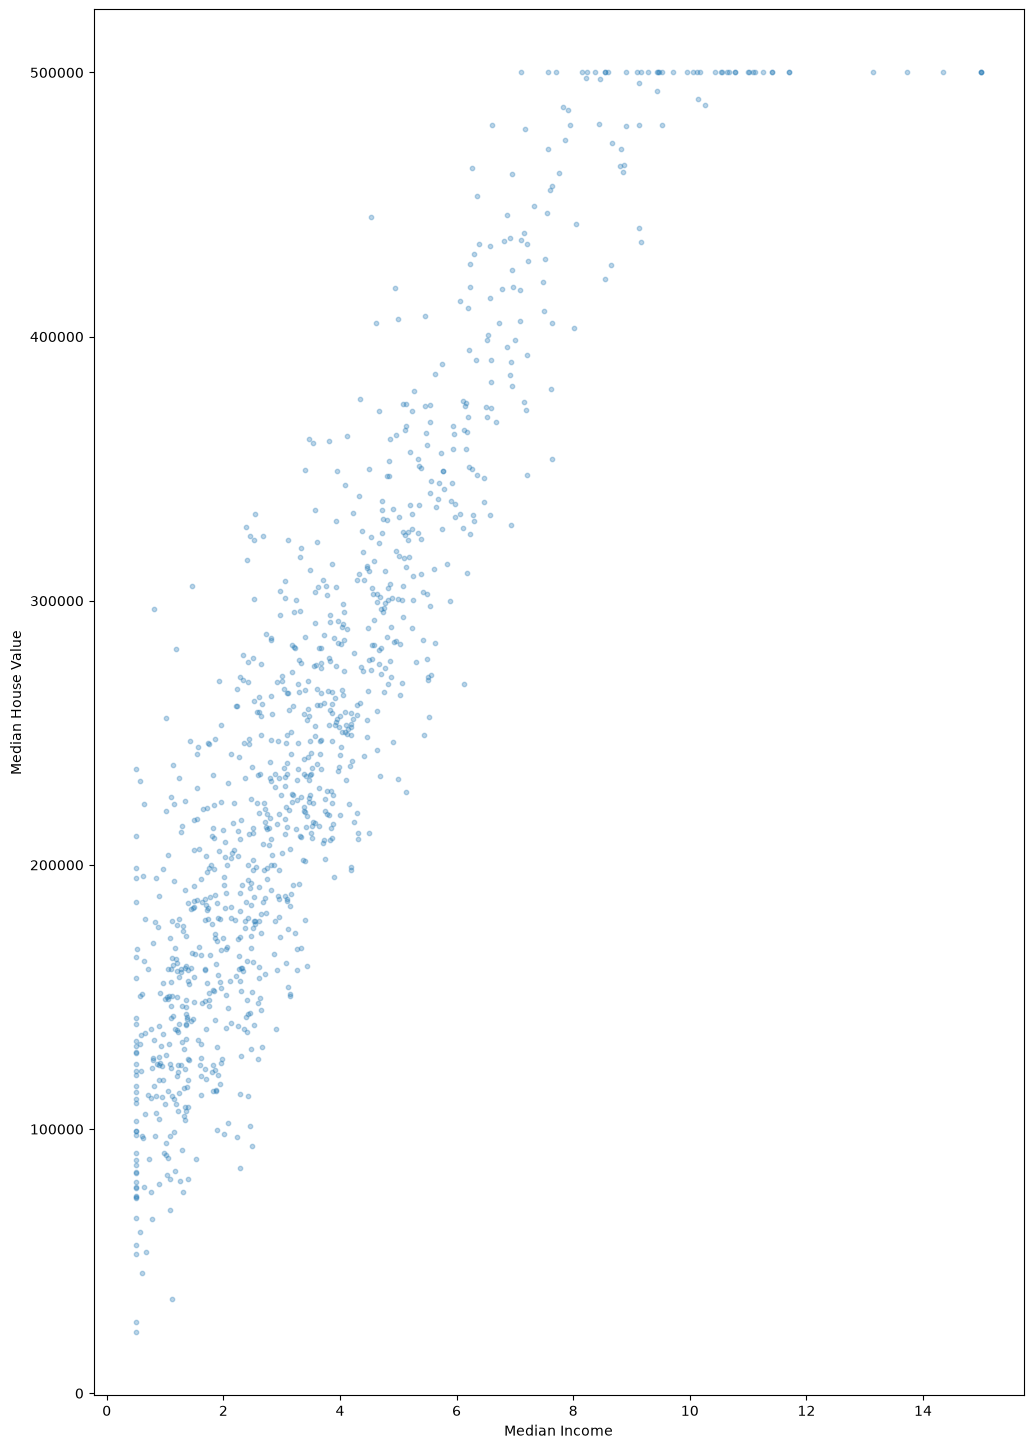

In [29]:
fig, ax = plt.subplots(figsize=(12,18))
ax.scatter(data["median_income"], data["median_house_value"], alpha=0.3, s=10)
ax.set_xlabel("Median Income")
ax.set_ylabel("Median House Value")
plt.show()

### Bar chart
### Mainly used to visualize the comparison between categories i.e. "Which category is bigger?"

C:\Users\yadny\AppData\Local\Temp\ipykernel_23260\1141595329.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(top_winners.index, rotation=90, ha="right")


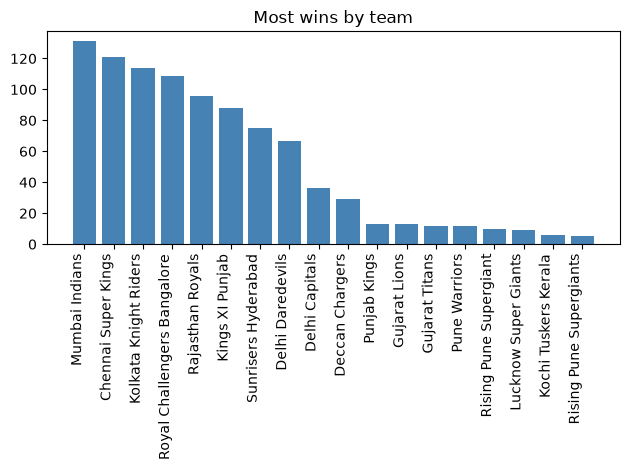

In [36]:
ipl = pd.read_csv("ipl-matches.csv")
top_winners = ipl["WinningTeam"].value_counts()

fig, ax = plt.subplots()
ax.bar(top_winners.index, top_winners.values, color="steelblue")
ax.set_xticklabels(top_winners.index, rotation=90, ha="right")
ax.set_title("Most wins by team")
plt.tight_layout()
plt.show()

### Horizontal Bar
#### Compare categories , same as bar chart , especially with long names/many categories

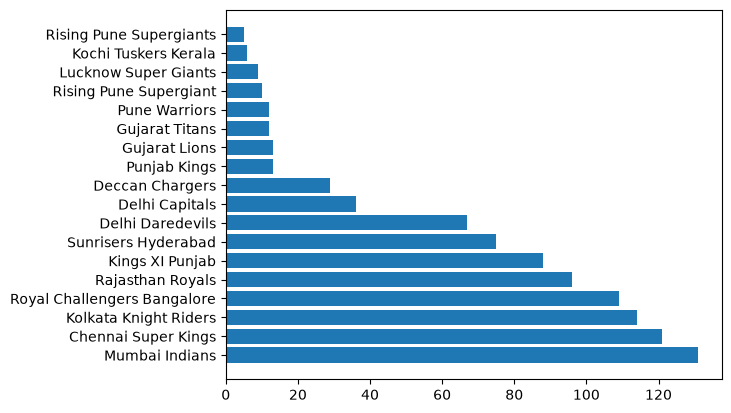

In [37]:
fig, ax = plt.subplots()
ax.barh(top_winners.index, top_winners.values)
plt.show()

### Histogram
#### Used to visualize distribution i.e. "how are numerical values distibuted?"

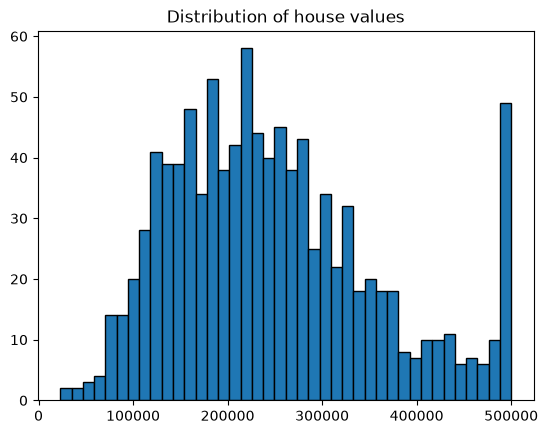

In [39]:
fig, ax = plt.subplots()
ax.hist(data["median_house_value"], bins=40, edgecolor="black")
ax.set_title("Distribution of house values")
plt.show()

### Box Plot
#### Distribution + outliers i.e. "What's the spread and are there outliers?"

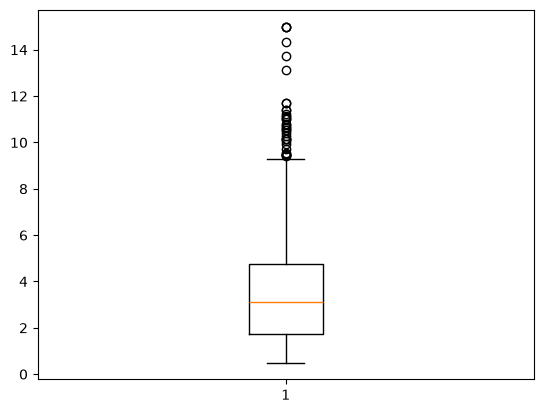

In [40]:
fig, ax = plt.subplots()
ax.boxplot(data["median_income"].dropna())
plt.show()

### Pie Chart
#### What percentage does each category contribute?

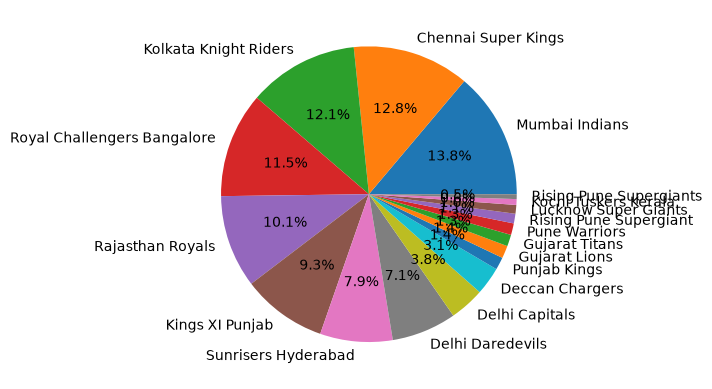

In [41]:
fig, ax = plt.subplots()
ax.pie(top_winners.values, labels=top_winners.index, autopct="%1.1f%%")
plt.show()

### Heatmap
#### "Where are the high/low values or correlations?"

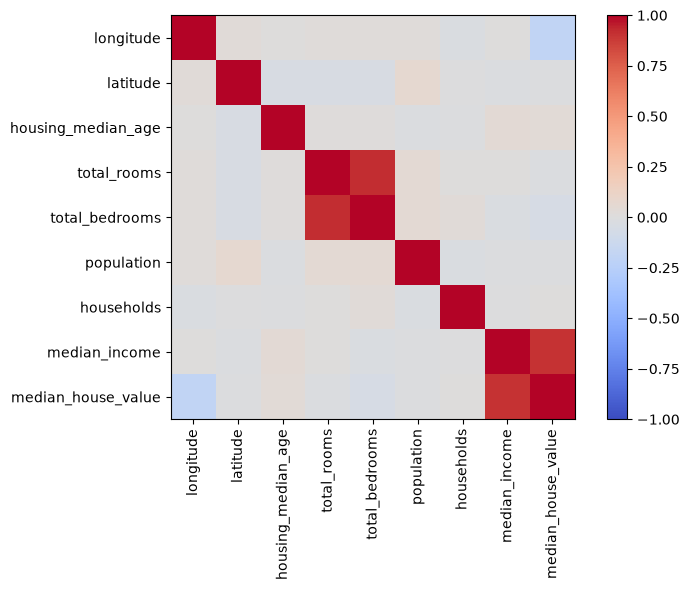

In [43]:
corr = data.select_dtypes("number").corr()
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.columns)))
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()